# CIFAR-10 Diffusion with Weights & Biases Logging

## Complete Beginner's Guide

This notebook introduces two important topics:

1. **CIFAR-10**: Moving from grayscale Fashion MNIST to full-color images
2. **Weights & Biases (W&B)**: Professional experiment tracking and logging

### What You'll Learn

1. **CIFAR-10 Dataset**: Working with 32x32 color images
2. **Model Scaling**: Comparing small vs large UNet architectures
3. **W&B Integration**: Tracking experiments, logging metrics, visualizing samples
4. **Custom Callbacks**: Building a WandBCB callback for seamless logging

### Prerequisites
- Basic Python knowledge
- Understanding of DDPM from previous notebooks
- A free Weights & Biases account (https://wandb.ai)

### Fashion MNIST vs CIFAR-10

```
Fashion MNIST:              CIFAR-10:
- 28x28 pixels              - 32x32 pixels
- Grayscale (1 channel)     - Color (3 channels: RGB)
- Clothing items            - Real-world objects
- 10 classes                - 10 classes
- ~60K images               - ~60K images
- Easier to generate        - More challenging
```

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, install required packages, and clone the `miniai` library from the fast.ai Part 2 course repo.

**GPU note:** Training on CIFAR-10 needs a GPU. **Runtime &rarr; GPU**.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [3]:
!pip install -q fastcore fastai diffusers datasets torcheval accelerate wandb
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))
try:
    import miniai
    print(f'miniai loaded from: {miniai.__file__}')
except ImportError:
    print('ERROR: miniai not found.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 6.0 MB/s eta 0:00:00
miniai loaded from: /content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/__init__.py


---

*The cells above are Colab-specific setup. The content below is the same as the source notebook (`21_cifar10_and_wandb_explained.ipynb`), unchanged.*

---

---
## 🛠️ Interactive visualizations — one-time setup

The cells marked **🎮 Interactive** below embed standalone HTML/JS visualizations
(published in the `interactive_viz/` folder on GitHub Pages) at **full width**, auto-fitted
to their content height (no empty space below). Run the next cell once, then run any 🎮 cell.


In [4]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> (its CSS/JS can't leak
# into the notebook). It is shown FULL WIDTH and auto-fits its content height.
# No local files needed -- the visualizations are read from GitHub.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="ce-frame-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

---
## Imports

In [5]:
# HuggingFace diffusers - provides the UNet architecture
from diffusers import UNet2DModel

# Standard Python libraries
import pickle,gzip,math,os,time,shutil,torch,random,logging
import fastcore.all as fc  # Fast.ai utilities
import matplotlib as mpl   # Plotting configuration
import numpy as np         # Numerical operations
import matplotlib.pyplot as plt  # Plotting
from collections.abc import Mapping
from pathlib import Path
from functools import partial  # Create functions with pre-filled arguments

# FastCore utilities
from fastcore.foundation import L

# PyTorch and torchvision
import torchvision.transforms.functional as TF  # Image transformations
import torch.nn.functional as F  # Neural network functions
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init  # Weight initialization
from torch.optim import lr_scheduler  # Learning rate schedulers

# miniai - Fast.ai's minimal library
from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *
from miniai.augment import *
from miniai.accel import *

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


**New import**: `UNet2DModel` from diffusers. This is the same architecture we used for Fashion MNIST, but now we'll configure it for 3-channel (RGB) images.

In [6]:
# Evaluation metrics and HuggingFace datasets
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset, load_dataset_builder

# Configure matplotlib (gray_r is for grayscale, but CIFAR-10 is color)
mpl.rcParams['image.cmap'] = 'gray_r'

# Suppress warning messages for cleaner output
logging.disable(logging.WARNING)

---
## Loading CIFAR-10 Dataset

CIFAR-10 contains 60,000 32x32 color images in 10 classes:
- airplane, automobile, bird, cat, deer
- dog, frog, horse, ship, truck

In [8]:
# Column names in CIFAR-10 dataset
# Note: CIFAR-10 uses 'img' instead of 'image' (different from Fashion MNIST)
xl, yl = 'img', 'label'

# Dataset name
name = "uoft-cs/cifar10"

# Load from HuggingFace
dsd = load_dataset(name)

# Define transformation
@inplace  # Modifies input dictionary in place
def transformi(b):
    # Convert PIL images to tensors and center around 0
    # TF.to_tensor: PIL -> tensor with values [0, 1]
    # -0.5: Shift to [-0.5, 0.5] range
    b[xl] = [TF.to_tensor(o) - 0.5 for o in b[xl]]

# Batch size - smaller than Fashion MNIST because:
# 1. CIFAR-10 has 3 channels (3x memory per image)
# 2. We'll use a larger model
bs = 32

# Apply transformation and create DataLoaders
tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=8)

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


**Key differences from Fashion MNIST:**

| Aspect | Fashion MNIST | CIFAR-10 |
|--------|---------------|----------|
| Column name | 'image' | 'img' |
| Image size | 28x28 | 32x32 |
| Channels | 1 (grayscale) | 3 (RGB) |
| Padding needed | Yes (to 32x32) | No |
| Batch size | 512 | 32 (due to memory) |

In [9]:
# Get a batch of training data
dt = dls.train
xb, yb = next(iter(dt))  # xb = images, yb = labels

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [10]:
# Check the shape of a batch
# Note: xb[0] is the first image in the batch, but xb itself is the whole batch
xb[0].shape

torch.Size([3, 32, 32])

**Careful — a very common shape confusion!**

The output above is `torch.Size([3, 32, 32])`, because `xb[0]` is **one image** taken out of the batch:

| Expression | Shape | Meaning |
|---|---|---|
| `xb.shape` | `[32, 3, 32, 32]` | the **whole batch**: 32 images × 3 channels × 32 × 32 |
| `xb[0].shape` | `[3, 32, 32]` | **one image**: 3 channels (R, G, B) × height 32 × width 32 |

Reading `[32, 3, 32, 32]` left to right: **batch size, channels, height, width** — the standard PyTorch
`NCHW` layout. Whenever a shape error appears in this notebook, checking which of these two you're holding
is the first thing to do.


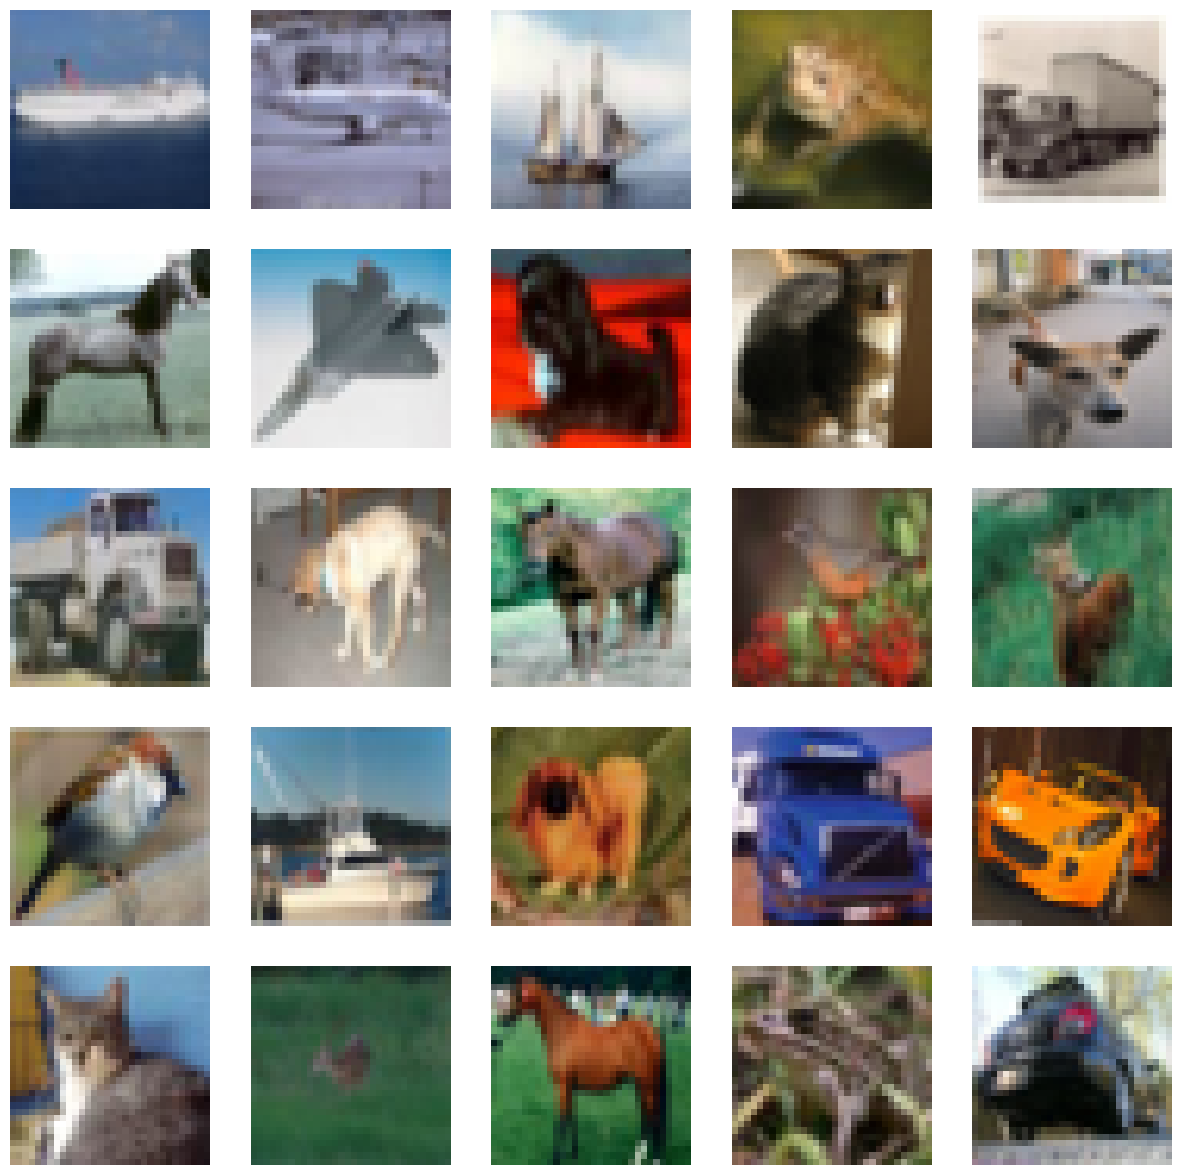

In [11]:
# Display some CIFAR-10 images
# +0.5 shifts values from [-0.5, 0.5] back to [0, 1] for display
show_images(xb[:25] + 0.5)

**What you should see**: Small 32x32 color images of planes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. The low resolution makes them appear blurry, but they're still recognizable.

**Challenge**: Generating realistic CIFAR-10 images is harder than Fashion MNIST because:
1. Color adds complexity (3x the information)
2. Real-world objects have more varied textures and shapes
3. Small details matter more (eyes, wheels, etc.)

### 🎮 Interactive: from grayscale to color — what `transformi` really does

Before going further, make sure the data itself is crystal clear: a color image is **three stacked 32×32 grids**
(channels), and `transformi` turns each PIL image into a zero-centered tensor. This playground walks the full
journey: PIL → channels → `to_tensor` (0–1) → `−0.5` (centered) → `[3, 32, 32]` → batch `[32, 3, 32, 32]`.

**What to try**
- **Hover any image** to read the real R/G/B values at that pixel — watch them change from `0–255` ints to
  `−0.5…0.5` floats as you advance stages.
- At stage ②, **toggle R / G / B off** and watch the car lose each color component.
- At stage ⑤, see the three channels as the grayscale planes the network actually receives.
- Stage ⑥ nails the classic confusion: `xb.shape` (whole batch) vs `xb[0].shape` (one image).


In [12]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/cifar_rgb_pipeline.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The file is read from the published GitHub Pages copy of this repo.
# ============================================================================
show_viz("interactive_viz/cifar_rgb_pipeline.html", height="820px")

---
## Setting Up the Noise Schedule

We use the same linear noise schedule as before.

In [13]:
from types import SimpleNamespace

def linear_sched(betamin=0.0001, betamax=0.02, n_steps=1000):
    """
    Create a linear noise schedule.

    Args:
        betamin: Starting variance (small noise at t=0)
        betamax: Ending variance (large noise at t=T)
        n_steps: Total number of diffusion steps

    Returns:
        SimpleNamespace containing:
        - a: alpha values (1 - beta)
        - abar: alphabar values (cumulative product of alphas)
        - sig: sigma values (sqrt of beta)
    """
    # Create linearly spaced beta values
    beta = torch.linspace(betamin, betamax, n_steps)

    return SimpleNamespace(
        a=1.-beta,                      # alpha = 1 - beta
        abar=(1.-beta).cumprod(dim=0),  # alphabar = cumulative product
        sig=beta.sqrt()                 # sigma = sqrt(beta)
    )

In [14]:
# Set up the schedule
n_steps = 1000  # Total diffusion steps
lin_abar = linear_sched(betamax=0.01)  # Using reduced betamax

# Extract the key values
alphabar = lin_abar.abar  # Cumulative signal preservation
alpha = lin_abar.a        # Per-step signal preservation
sigma = lin_abar.sig      # Per-step noise std dev

**Same schedule as Fashion MNIST**: The noise schedule doesn't depend on whether images are grayscale or color - it only depends on the number of timesteps.

### 🎮 Interactive: the noise schedule, live — and why `betamax=0.01`

The entire forward process is controlled by the tiny table `linear_sched` returns. Here you can *see* it:
β rises linearly, while **ᾱ = cumprod(α)** decays smoothly — and its value at each timestep sets exactly how
much signal survives.

**What to try**
- Press **Play ▶** (or drag on the plot / the **t slider**) and watch the image blend from clean frog to pure
  noise as `√ᾱ` and `√(1−ᾱ)` trade places.
- Toggle **betamax** between `0.01` (this notebook) and `0.02` (the DDPM paper) — with 0.02 the signal is
  essentially gone by step ~500; the gentler 0.01 spends more of the schedule at informative noise levels.
- Park at `t = 999` and read the signal pill: ᾱ ≈ 0 — the endpoint really is indistinguishable from
  `torch.randn`, which is why sampling can *start* from pure noise.


In [15]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/noise_schedule_lab_2.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The file is read from the published GitHub Pages copy of this repo.
# ============================================================================
show_viz("interactive_viz/noise_schedule_lab_2.html", height="100vh")

---
## The Noisify Function

This adds noise to clean images during training.

In [16]:
def noisify(x0, alphabar):
    """
    Add noise to clean images for DDPM training.

    Formula: x_t = sqrt(alphabar_t) * x_0 + sqrt(1 - alphabar_t) * epsilon

    Args:
        x0: Clean images, shape (batch, channels, height, width)
        alphabar: Tensor of cumulative alpha values

    Returns:
        ((noisy_images, timesteps), noise)
    """
    device = x0.device
    n = len(x0)  # Batch size

    # Sample random timesteps for each image
    t = torch.randint(0, n_steps, (n,), dtype=torch.long)

    # Generate random Gaussian noise (same shape as images)
    epsilon = torch.randn(x0.shape, device=device)

    # Get alphabar values for sampled timesteps
    # Reshape for broadcasting: (batch,) -> (batch, 1, 1, 1)
    alphabar_t = alphabar[t].reshape(-1, 1, 1, 1).to(device)

    # Forward diffusion formula
    xt = alphabar_t.sqrt() * x0 + (1 - alphabar_t).sqrt() * epsilon

    return (xt, t.to(device)), epsilon

**Same function, different data**: The noisify function works identically for grayscale and color images because:
- `torch.randn(x0.shape)` automatically matches the shape (including channels)
- The formula applies element-wise to all channels

### 🎮 Interactive: follow a mini-batch through `noisify()`

Training never runs the 1000-step chain — `noisify` jumps every image **directly** to a random timestep with
one formula. This playground pushes a batch of 4 images through the function, stage by stage, with the current
line of code highlighted.

**What to try**
- Step through the stages: sample **t** → sample **ε** → gather **ᾱₜ** and reshape `[4] → [4,1,1,1]` → mix.
- Press **Re-roll 🎲** to draw new random timesteps and noise — every image gets a *different* corruption level,
  which is exactly what makes one batch cover many noise levels at once.
- At stage ④, focus on the **broadcasting**: one scalar per image, stretched across all `3×32×32` values.
- At stage ⑤, compare the four results with their `√ᾱ` / `√(1−ᾱ)` chips — small t keeps the image, large t destroys it.


In [17]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/noisify_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The file is read from the published GitHub Pages copy of this repo.
# ============================================================================
show_viz("interactive_viz/noisify_explorer.html", height="1000px")

In [18]:
# Test noisify with some images
(xt, t), epsilon = noisify(xb[:25], alphabar)
t  # Show sampled timesteps

tensor([653, 436, 513, 755, 938,  62, 968, 243, 696, 311, 414, 579,  67, 606,
        318, 678, 941, 500, 660,  88, 666, 851, 783, 896, 111])

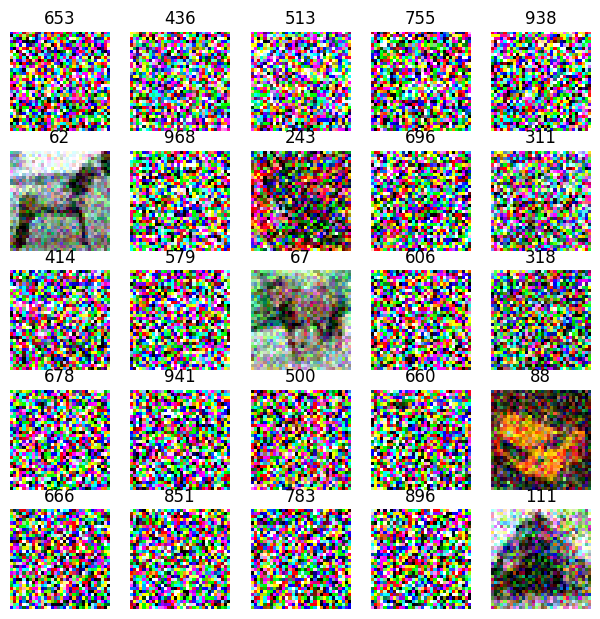

In [19]:
# Display noisy images with their timesteps
titles = fc.map_ex(t[:25], '{}')  # Convert timesteps to strings

# .clip(-0.5, 0.5) ensures values stay in valid range
# +0.5 shifts to [0, 1] for display
show_images(xt[:25].clip(-0.5, 0.5) + 0.5, imsize=1.5, titles=titles)

**What to observe:**
- Low timesteps (e.g., 158, 175): Image mostly visible, slight noise
- Medium timesteps (e.g., 400-600): Partial visibility
- High timesteps (e.g., 800-990): Mostly noise, original barely visible

---
# Training

Now let's set up training for CIFAR-10. The main changes from Fashion MNIST are:
1. **3 input/output channels** instead of 1
2. **Larger model** (optionally) for better quality
3. **Smaller batch size** due to memory constraints

In [20]:
class UNet(UNet2DModel):
    """
    Thin wrapper around HuggingFace's UNet2DModel.

    The wrapper unpacks the (image, timestep) tuple and extracts
    the .sample from the output.
    """
    def forward(self, x):
        # x is (noisy_images, timesteps)
        # *x unpacks to separate arguments
        # .sample extracts the tensor from the output named tuple
        return super().forward(*x).sample


def init_ddpm(model):
    """
    Initialize UNet weights for stable DDPM training.

    Key ideas:
    1. Zero out final convs in residual blocks (start as identity)
    2. Orthogonal init for downsamplers (preserve magnitude)
    3. Zero out final output conv (start predicting zero noise)
    """
    # Initialize down blocks (encoder)
    for o in model.down_blocks:
        for p in o.resnets:
            p.conv2.weight.data.zero_()  # Zero last conv in each resnet
            for p in fc.L(o.downsamplers):
                init.orthogonal_(p.conv.weight)  # Orthogonal for downsamplers

    # Initialize up blocks (decoder)
    for o in model.up_blocks:
        for p in o.resnets:
            p.conv2.weight.data.zero_()

    # Zero the final output convolution
    model.conv_out.weight.data.zero_()


def collate_ddpm(b):
    """
    Custom collate function for DDPM training.
    Converts (images, labels) to ((noisy_images, timesteps), noise).
    """
    return noisify(default_collate(b)[xl], alphabar) # xl = 'image'


def dl_ddpm(ds, nw=4):
    """
    Create a DataLoader for DDPM training.

    Args:
        ds: Dataset
        nw: Number of worker processes
    """
    return DataLoader(ds, batch_size=bs, collate_fn=collate_ddpm, num_workers=nw)

In [21]:
# Create DataLoaders
dls = DataLoaders(dl_ddpm(tds['train']), dl_ddpm(tds['test']))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# Understanding `fc.L()` and `downsamplers` in UNet

## What is `fc.L()`?

`fc.L` comes from the **fastcore** library (imported as `import fastcore.all as fc` at the top of the notebook). It's a list-like class that provides extra functionality.

The key thing here: **`fc.L()` safely handles `None` values**.

```python
fc.L(None)  # Returns an empty L() - you can iterate over it without errors
fc.L([1, 2, 3])  # Returns L([1, 2, 3]) - works like a normal list
```

## What are `downsamplers`?

In a UNet architecture, **downsamplers** are the layers that **reduce the spatial resolution** (height and width) of the feature maps as you go deeper into the encoder.

```
UNet Encoder (Down Blocks):

Input Image: 32×32
    │
    ▼
[Down Block 1] ──► ResNets process features
    │
    ▼
[Downsampler] ──► Reduces 32×32 → 16×16  (usually a strided conv or pooling)
    │
    ▼
[Down Block 2] ──► ResNets process features
    │
    ▼
[Downsampler] ──► Reduces 16×16 → 8×8
    │
    ▼
[Down Block 3] ──► ResNets process features
    │
    ▼
[Downsampler] ──► Reduces 8×8 → 4×4
    │
    ...
```

## Why use `fc.L(o.downsamplers)`?

Here's the critical insight: **not every down block has a downsampler!**

The **last down block** typically doesn't have one (no need to shrink further at the bottleneck). In HuggingFace's UNet2DModel:

- Blocks with downsamplers: `o.downsamplers = [Downsample2D(...)]`
- The final block: `o.downsamplers = None`

If you wrote `for p in o.downsamplers:` and `o.downsamplers` is `None`, you'd get an error:
```
TypeError: 'NoneType' object is not iterable
```

**`fc.L()` solves this** by converting `None` to an empty list that can be safely iterated:

```python
for p in fc.L(o.downsamplers):  # Works even if downsamplers is None
    init.orthogonal_(p.conv.weight)
```

This is a clean, defensive programming pattern common in the fast.ai ecosystem.

### 🎮 Interactive: watch one tensor travel through the UNet in 3D

Everything from the last two sections in one animated 3D scene. The thin panels are the model's blocks —
`conv_in`, the four down blocks and their downsamplers, the bottleneck, the four up blocks, `conv_out` —
and the **solid box is the data itself**, morphing at every block: its **face** is the pixel grid
(32×32 → 4×4 → 32×32) and its **thickness** is the channel count (3 → 256 → 3). *(Needs internet access:
loads three.js from cdnjs.)*

**What to try**
- Press **▶ Play all** (or **⏭ one block at a time**) and watch the encoder squeeze the box smaller-and-fatter,
  each down block **parking a copy on a shelf** — those are the future skip connections.
- Don't miss the **dashed empty frame** after Down 4: `downsamplers = None`. The box passes through unchanged —
  the visual reason `fc.L()` exists in `init_ddpm`.
- In the decoder, watch each **shelf copy fly down the arc and visibly fatten the box** — that's
  `torch.cat` along the channel dimension (256+256 → 512, then 256+128, 128+64, 64+32).
- The **gold dot** riding the box is the timestep embedding, injected into every glowing block.
- **Click any block** for its shapes and its `init_ddpm` treatment; the **story chips replay** each part of the
  journey, and the shape **pills** below the scene jump straight to any waypoint.


In [22]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/unet_3d_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The file is read from the published GitHub Pages copy of this repo.
# ============================================================================
show_viz("interactive_viz/unet_3d_explorer.html", height="1280px")

---
## Comparing Model Sizes

Let's compare a small model (like we used for Fashion MNIST) with the default larger model.

In [23]:
# Small model - same architecture as Fashion MNIST but with 3 channels
model = UNet(
    in_channels=3,                          # RGB input
    out_channels=3,                         # RGB output (predicted noise)
    block_out_channels=(32, 64, 128, 256),  # Channel progression
    norm_num_groups=8                       # Groups for GroupNorm
)

# Count parameters
small_params = sum(p.numel() for p in model.parameters())
print(f"Small model parameters: {small_params:,}")

Small model parameters: 15,891,907


**~15.9 million parameters** - This is the "small" model we've been using.

In [24]:
# Default (large) model - uses default block_out_channels
model = UNet(
    in_channels=3,   # RGB input
    out_channels=3   # RGB output
    # block_out_channels defaults to (320, 640, 1280, 1280)
)

# Count parameters
large_params = sum(p.numel() for p in model.parameters())
print(f"Large model parameters: {large_params:,}")

Large model parameters: 274,056,163


**~274 million parameters** - This is **17x larger** than the small model!

**Model size comparison:**

| Model | Parameters | block_out_channels | Memory | Quality |
|-------|------------|-------------------|--------|--------|
| Small | ~16M | (32, 64, 128, 256) | Low | Lower |
| Default | ~274M | (320, 640, 1280, 1280) | High | Higher |

**Trade-offs:**
- Larger models produce better quality but need more GPU memory and time
- For experimentation, start with the small model
- For final results, use the larger model

# Why Does the Default UNet Have So Many More Parameters?

Great question! The key difference is in the **`block_out_channels`** parameter, which controls the **width** (number of filters) at each level of the UNet.

## Comparing the Two Models

| Model | `block_out_channels` | Parameters |
|-------|---------------------|------------|
| Small (explicit) | `(32, 64, 128, 256)` | ~16M |
| Default (implicit) | `(320, 640, 1280, 1280)` | ~274M |

When you don't specify `block_out_channels`, HuggingFace uses its **default values**, which are much larger.

## Why Does This Matter So Much?

The number of parameters in a convolutional layer scales with the **square** of the channel count:

```
Conv layer params ≈ (in_channels × out_channels × kernel_size²)
```

Let's compare just **one layer** at the deepest level:

```
Small model:  128 → 256 channels, 3×3 kernel
Params = 128 × 256 × 9 = 294,912

Default model: 1280 → 1280 channels, 3×3 kernel  
Params = 1280 × 1280 × 9 = 14,745,600
```

That's **50× more parameters** in just one layer!

## Visual Comparison

```
Small Model (32, 64, 128, 256):

Level 1:  32 filters   ████
Level 2:  64 filters   ████████
Level 3: 128 filters   ████████████████
Level 4: 256 filters   ████████████████████████████████


Default Model (320, 640, 1280, 1280):

Level 1:  320 filters  ████████████████████████████████████████
Level 2:  640 filters  ████████████████████████████████████████████████...
Level 3: 1280 filters  ████████████████████████████████████████████████████████...
Level 4: 1280 filters  ████████████████████████████████████████████████████████...
```

The `in_channels=3` and `out_channels=3` only affect the **very first** and **very last** layers of the network — everything in between is determined by `block_out_channels`.

### 🎮 Interactive: where do 274M parameters actually live?

The tables above tell you *that* the default model is ~17× bigger. This visualization shows you **why**:
conv parameters scale with `in_channels × out_channels`, so widening every level ~10× costs ~100× per layer —
and the deepest levels dominate the total.

**What to try**
- **Click each level row** — the exact parameter math for one 3×3 conv at that depth appears on the right
  (level 4 is the shocker: one conv ≈ 14.7M parameters, nearly the whole small model).
- Toggle **Linear / Log scale** — on the linear scale, levels 1–2 of the small model all but vanish.
- Switch to **Rough level totals** to see the same square-law pattern across whole levels.


In [25]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/unet_size_comparator.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The file is read from the published GitHub Pages copy of this repo.
# ============================================================================
show_viz("interactive_viz/unet_size_comparator.html", height="1140px")

In [26]:
# Free up GPU memory before training
clean_mem()

`clean_mem()` calls garbage collection and empties the CUDA cache. This is helpful when switching between different model sizes.

---
## Training Setup

In [27]:
# Training hyperparameters
lr = 1e-3      # Learning rate
epochs = 1     # Number of epochs (just 1 for quick demo)

# Optimizer: AdamW with small epsilon for stability
opt_func = partial(optim.AdamW, eps=1e-5)

# Total training steps (for learning rate scheduler)
tmax = epochs * len(dls.train)

# OneCycleLR: Learning rate ramps up then down
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)

# Callbacks for training
cbs = [
    DeviceCB(),          # Move data to GPU
    MixedPrecision(),    # Use FP16 for faster training
    ProgressCB(plot=True),  # Progress bar and loss plot
    MetricsCB(),         # Track metrics
    BatchSchedCB(sched)  # Update LR each batch
]

# Create the large model
model = UNet(in_channels=3, out_channels=3)

# Apply DDPM initialization
init_ddpm(model)

# Create the Learner
learn = Learner(
    model,
    dls,
    nn.MSELoss(),  # Mean Squared Error loss
    lr=lr,
    cbs=cbs,
    opt_func=opt_func
)

/content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/accel.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  def before_fit(self, learn): self.scaler = torch.cuda.amp.GradScaler()


loss,epoch,train
0.055,0,train
0.027,0,eval


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


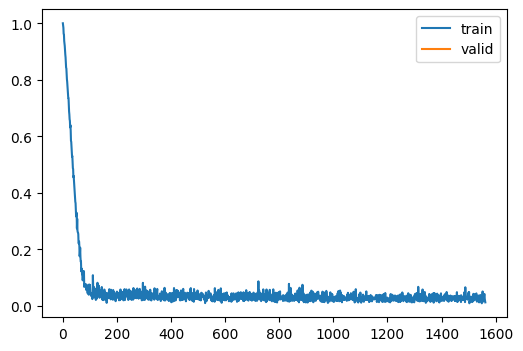

In [28]:
# Train for 1 epoch (this is just a demo - real training needs more epochs)
learn.fit(epochs)

**Note**: 1 epoch is not enough for good quality. For real results, you'd train for 50-100+ epochs. We use 1 here just to demonstrate the pipeline.

---
## Sampling Function

Generate images from the trained model.

In [29]:
@torch.no_grad()  # Disable gradient computation
def sample(model, sz):
    """
    Generate images by running the reverse diffusion process.

    Args:
        model: Trained DDPM model
        sz: Shape of images to generate (batch, channels, height, width)

    Returns:
        List of intermediate predictions at each timestep
    """
    # Get device and dtype from model
    ps = next(model.parameters())

    # Start from pure random noise
    x_t = torch.randn(sz).to(ps)
    preds = []

    # Iterate backwards from t=999 to t=0
    for t in reversed(range(n_steps)):
        # Create timestep batch
        t_batch = torch.full((x_t.shape[0],), t, device=ps.device, dtype=torch.long)

        # Random noise (zero at final step)
        z = (torch.randn(x_t.shape) if t > 0 else torch.zeros(x_t.shape)).to(ps)

        # Get alphabar for previous timestep
        alphabar_t1 = alphabar[t-1] if t > 0 else torch.tensor(1)

        # Betabar values
        betabar_t = 1 - alphabar[t]
        betabar_t1 = 1 - alphabar_t1

        # Model predicts noise
        noise = model((x_t, t_batch))

        # Estimate clean image
        x_0_hat = (x_t - betabar_t.sqrt() * noise) / alphabar[t].sqrt()

        # Compute x_{t-1}
        x_t = (x_0_hat * alphabar_t1.sqrt() * (1-alpha[t]) / betabar_t +
               x_t * alpha[t].sqrt() * betabar_t1 / betabar_t +
               sigma[t] * z)

        preds.append(x_t.float().cpu())

    return preds

# Understanding `ps` and `.to(ps)` in PyTorch Sampling Code

## What is `ps`?

`ps` stands for **"parameters"** (or you can think of it as "param sample"). It's grabbing **one parameter tensor** from the model.

```python
ps = next(model.parameters())
```

### What does this line do?

- `model.parameters()` returns an **iterator** over all the model's weight tensors
- `next(...)` grabs just the **first one** (any parameter will do)

**Why do this?** We need to know:
1. **Which device** the model is on (CPU or GPU)
2. **What dtype** the model uses (float32, float16, bfloat16, etc.)

Instead of manually tracking `device` and `dtype`, we just grab a parameter that already has both!

---

## What does `.to(ps)` do?

```python
x_t = torch.randn(sz).to(ps)
```

This is a **clever shortcut**! When you call `.to()` with another tensor (instead of a device string), PyTorch copies **both the device AND dtype** from that tensor.

### The Long Way (Explicit)
```python
x_t = torch.randn(sz).to(device='cuda:0', dtype=torch.float16)
```

### The Short Way (Using `ps`)
```python
x_t = torch.randn(sz).to(ps)  # Automatically matches device AND dtype of ps
```

---

## Why This Pattern?

This pattern is useful because:

```
Scenario 1: Model on CPU with float32
    ps.device = 'cpu'
    ps.dtype = torch.float32
    → x_t created on CPU with float32

Scenario 2: Model on GPU with mixed precision (float16)
    ps.device = 'cuda:0'  
    ps.dtype = torch.float16
    → x_t created on GPU with float16
```

**One line of code handles all cases!** This is especially important when using mixed precision training (like the `MixedPrecision()` callback in the notebook).

### 🎮 Interactive: one reverse-diffusion step, dissected

The `sample()` loop above runs **1000 times**, and every iteration does the same four things. This playground
lets you scrub the timestep from 999 → 0 and watch an image emerge from static, while dissecting a single step:
predict the noise **ε̂**, estimate the clean image **x̂₀**, blend it with the current image, then add back a pinch
of fresh noise **σ·z**.

**What to try**
- Press **Play 999→0 ▶** and watch the frog appear — then drag the **t slider** to any point in the trajectory.
- **Click the four stages** — each highlights the exact lines of `sample()` it corresponds to.
- Watch the **weight pills** at stage ③: each step trusts `x_t` heavily and moves only a tiny way toward `x̂₀`.
  A thousand tiny corrections, not one big jump.
- Go to `t = 0` and check stage ④: `z = zeros` — the very last step adds **no** noise.


In [30]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/ddpm_sampling_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The file is read from the published GitHub Pages copy of this repo.
# ============================================================================
show_viz("interactive_viz/ddpm_sampling_explorer.html", height="1020px")

In [31]:
%%time
# Generate samples
# Shape: (batch_size, 3 channels, 32 height, 32 width)
samples = sample(model, (bs, 3, 32, 32))

CPU times: user 5min 31s, sys: 265 ms, total: 5min 31s
Wall time: 5min 33s


Generating 32 samples takes about 1 minute with 1000 steps.

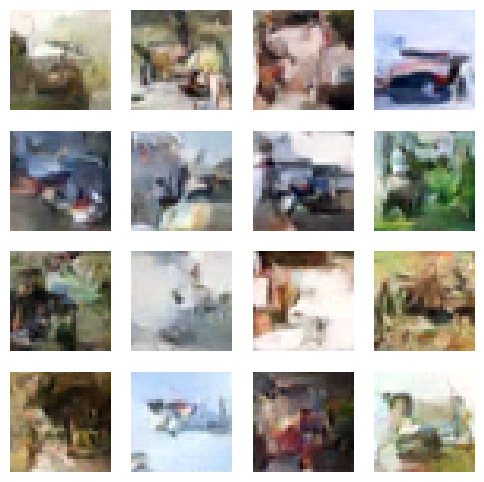

In [32]:
# Display generated samples
# +0.5 shifts from [-0.5, 0.5] to [0, 1]
# .clamp(0, 1) ensures valid pixel values
s = (samples[-1] + 0.5).clamp(0, 1)
show_images(s[:16], imsize=1.5)

**With only 1 epoch of training**, the samples will look like noise or vague blobs. Real training requires 50-100+ epochs for recognizable images.

---
# Weights & Biases (W&B) Integration

## What is W&B?

Weights & Biases is a platform for machine learning experiment tracking. It helps you:

1. **Log metrics**: Track loss, accuracy, and custom metrics over time
2. **Visualize results**: Interactive plots and dashboards
3. **Compare experiments**: See how different hyperparameters affect results
4. **Share results**: Collaborate with team members
5. **Log artifacts**: Save models, samples, and other outputs

### Why Use W&B?

```
Without W&B:                    With W&B:
- Print statements              - Automatic logging
- Manual spreadsheets           - Interactive dashboards
- Lost experiments              - Everything saved online
- Hard to compare               - Easy comparison
- "What settings did I use?"    - Full config saved
```

In [37]:
import wandb  # Import W&B library

class WandBCB(MetricsCB):
    """
    A callback that logs training metrics and samples to Weights & Biases.

    This callback:
    1. Initializes a W&B run when training starts
    2. Logs loss after each batch
    3. Logs metrics after each epoch
    4. Generates and logs sample images after each epoch
    5. Closes the W&B run when training ends

    Inherits from MetricsCB to get metric tracking functionality.
    """

    # Run order: higher numbers run later
    # 100 ensures this runs after other callbacks have computed metrics
    order = 100

    def __init__(self, config, *ms, project='ddpm_cifar10', **metrics):
        """
        Initialize the W&B callback.

        Args:
            config: Dictionary of hyperparameters to log
            *ms: Additional metrics to track
            project: W&B project name (groups related runs)
            **metrics: Named metrics to track
        """
        # fc.store_attr() stores all arguments as instance attributes
        # self.config = config, self.project = project, etc.
        fc.store_attr()

        # Initialize parent class (MetricsCB)
        super().__init__(*ms, **metrics)

    def before_epoch(self, learn):
        super().before_epoch(learn)
        self.train = learn.model.training

    def before_fit(self, learn):
        """
        Called before training starts.
        Initialize a new W&B run.
        """
        # wandb.init() starts a new run
        # - project: Groups runs together
        # - config: Logs hyperparameters (visible in W&B dashboard)
        wandb.init(project=self.project, config=self.config)

    def after_fit(self, learn):
        """
        Called after training ends.
        Close the W&B run.
        """
        wandb.finish()  # Marks run as complete

    def _log(self, d):
        """
        Log metrics after each epoch.

        Args:
            d: Dictionary of metric values from MetricsCB
        """
        if self.train:
            # Log training metrics with 'train_' prefix
            wandb.log({'train_' + m: float(d[m]) for m in self.all_metrics})
        else:
            # Log validation metrics with 'val_' prefix
            wandb.log({'val_' + m: float(d[m]) for m in self.all_metrics})

            # Also log sample images after validation
            wandb.log({'samples': self.sample_figure(learn)})

        # Still print metrics to console
        print(d)

    def sample_figure(self, learn):
        """
        Generate sample images and create a matplotlib figure.

        This is called after each validation epoch to visualize
        the current quality of generated images.

        Args:
            learn: The Learner object

        Returns:
            matplotlib Figure object
        """
        with torch.no_grad():
            # Generate 16 samples
            samples = sample(learn.model, (16, 3, 32, 32))

        # Process samples for display
        s = (samples[-1] + 0.5).clamp(0, 1)

        # Clear any existing figure
        plt.clf()

        # Create a grid of images
        fig, axs = get_grid(16)  # 4x4 grid
        for im, ax in zip(s[:16], axs.flat):
            show_image(im, ax=ax)

        return fig

    def after_batch(self, learn):
        """
        Called after each batch.
        Log the batch loss to W&B.
        """
        # First call parent's after_batch (updates metrics)
        super().after_batch(learn)

        # Log the loss for this batch
        wandb.log({'loss': learn.loss})

**WandBCB Callback Flow:**

```
Training starts
    |
    v
before_fit() --> wandb.init()
    |
    v
For each epoch:
    |
    v
  For each batch:
      |
      v
    after_batch() --> wandb.log({'loss': ...})
    |
    v
  End of epoch:
      |
      v
    _log() --> wandb.log({'train_loss': ...})
           --> wandb.log({'val_loss': ...})
           --> wandb.log({'samples': figure})
    |
    v
Training ends
    |
    v
after_fit() --> wandb.finish()
```

# Understanding the WandBCB Callback Class

## Project Creation - It Happens Automatically!

You **don't need to create the project beforehand** in Weights & Biases. When you call `wandb.init(project='ddpm_cifar10', ...)`, W&B will:

1. **Check if the project exists** → Use it if it does
2. **Create it automatically** → If it doesn't exist

So the first time you run training with `project='ddpm_cifar10'`, W&B creates the project for you.

### How It Works

```python
# First run ever with this project name:
wandb.init(project='ddpm_cifar10', config=config)
# → W&B: "Project 'ddpm_cifar10' doesn't exist. Creating it now!"

# Second run:
wandb.init(project='ddpm_cifar10', config=config)
# → W&B: "Project 'ddpm_cifar10' exists. Adding this run to it."

# Different project name:
wandb.init(project='my_new_experiment', config=config)
# → W&B: "Project 'my_new_experiment' doesn't exist. Creating it now!"
```

### Visual Example

```
Your W&B Account
    │
    ├── ddpm_cifar10/          ← Created automatically on first run
    │   ├── Run 1 (epoch 10)
    │   ├── Run 2 (epoch 25)
    │   └── Run 3 (epoch 50)
    │
    └── my_other_project/      ← Created when you use a different name
        └── Run 1
```

### Practical Tip

You can name your project anything you want:

```python
# These all work - projects are created on-the-fly
wandb.init(project='cifar10_experiments')
wandb.init(project='thesis_diffusion_models')
wandb.init(project='quick_test_delete_later')
```

The project name just helps you **organize related runs** together in your W&B dashboard.

---

## Complete WandBCB Class Explanation

```python
import wandb  # Import W&B library

class WandBCB(MetricsCB):
```

**Inheritance**: `WandBCB` inherits from `MetricsCB`, which already handles metric tracking (computing averages, storing values, etc.). We're adding W&B logging on top of that functionality.

---

### Class Attribute: `order = 100`

```python
order = 100
```

**What it does**: Controls when this callback runs relative to other callbacks.

- Lower numbers run **first**
- Higher numbers run **later**
- `order = 100` ensures WandBCB runs **after** other callbacks have finished computing metrics

```
Callback Execution Order:
    DeviceCB (order=0)      → Moves data to GPU
    MixedPrecision          → Sets up float16
    ProgressCB              → Updates progress bar
    WandBCB (order=100)     → Logs everything LAST (after metrics are ready)
```

---

### `__init__` Method

```python
def __init__(self, config, *ms, project='ddpm_cifar10', **metrics):
    fc.store_attr()
    super().__init__(*ms, **metrics)
```

**What it does**: Initializes the callback with configuration.

| Parameter | Purpose | Example |
|-----------|---------|---------|
| `config` | Hyperparameters to log | `{'lr': 1e-3, 'epochs': 10}` |
| `*ms` | Positional metric objects | `MulticlassAccuracy()` |
| `project` | W&B project name | `'ddpm_cifar10'` |
| `**metrics` | Named metrics | `accuracy=MulticlassAccuracy()` |

**`fc.store_attr()`**: A fastcore utility that automatically does:
```python
self.config = config
self.project = project
# etc.
```

---

### `before_fit` Method

```python
def before_fit(self, learn):
    wandb.init(project=self.project, config=self.config)
```

**When it's called**: Once, right before training starts.

**What it does**:
- Creates a new W&B "run"
- Connects to W&B servers
- Logs your hyperparameters (config)

```
Timeline:
    learn.fit(epochs) called
        │
        ▼
    before_fit() ──► wandb.init() ──► W&B Dashboard shows new run
        │
        ▼
    Training begins...
```

---

### `after_fit` Method

```python
def after_fit(self, learn):
    wandb.finish()
```

**When it's called**: Once, right after training ends.

**What it does**:
- Marks the run as complete
- Uploads any remaining data
- Closes the connection cleanly

```
Timeline:
    ...Training ends
        │
        ▼
    after_fit() ──► wandb.finish() ──► W&B shows run as "Finished"
```

---

### `_log` Method

```python
def _log(self, d):
    if self.train:
        wandb.log({'train_' + m: float(d[m]) for m in self.all_metrics})
    else:
        wandb.log({'val_' + m: float(d[m]) for m in self.all_metrics})
        wandb.log({'samples': self.sample_figure(learn)})
    print(d)
```

**When it's called**: After each epoch (inherited from MetricsCB).

**What it does**:

1. **During training phase** (`self.train = True`):
   - Logs metrics with `train_` prefix
   ```python
   {'train_loss': 0.045, 'train_accuracy': 0.92}
   ```

2. **During validation phase** (`self.train = False`):
   - Logs metrics with `val_` prefix
   - Also generates and logs sample images!
   ```python
   {'val_loss': 0.052, 'val_accuracy': 0.89}
   {'samples': <matplotlib figure>}
   ```

3. **Always**: Prints metrics to console so you can see progress locally.

---

### `sample_figure` Method

```python
def sample_figure(self, learn):
    with torch.no_grad():
        samples = sample(learn.model, (16, 3, 32, 32))
    
    s = (samples[-1] + 0.5).clamp(0, 1)
    
    plt.clf()
    fig, axs = get_grid(16)
    for im, ax in zip(s[:16], axs.flat):
        show_image(im, ax=ax)
    
    return fig
```

**When it's called**: After each validation epoch (called by `_log`).

**What it does** step by step:

```
Step 1: torch.no_grad()
    └── Disables gradient tracking (saves memory, faster)

Step 2: sample(learn.model, (16, 3, 32, 32))
    └── Generate 16 images, 3 channels (RGB), 32x32 pixels
    └── Returns list of predictions at each timestep

Step 3: samples[-1]
    └── Get the FINAL denoised images (index -1 = last item)

Step 4: + 0.5
    └── Shift from [-0.5, 0.5] to [0, 1] range

Step 5: .clamp(0, 1)
    └── Ensure values stay in valid range for display

Step 6: Create 4x4 grid of images
    └── plt.clf() clears any previous figure
    └── get_grid(16) creates 4x4 subplot grid
    └── Loop displays each image

Step 7: Return the figure
    └── W&B will render this as an image in the dashboard
```

**Visual result on W&B**:
```
┌────┬────┬────┬────┐
│ 🖼 │ 🖼 │ 🖼 │ 🖼 │
├────┼────┼────┼────┤
│ 🖼 │ 🖼 │ 🖼 │ 🖼 │
├────┼────┼────┼────┤
│ 🖼 │ 🖼 │ 🖼 │ 🖼 │
├────┼────┼────┼────┤
│ 🖼 │ 🖼 │ 🖼 │ 🖼 │
└────┴────┴────┴────┘
   16 generated samples
```

---

### `after_batch` Method

```python
def after_batch(self, learn):
    super().after_batch(learn)
    wandb.log({'loss': learn.loss})
```

**When it's called**: After every single batch.

**What it does**:

1. **`super().after_batch(learn)`**: Call parent's method first (MetricsCB updates its running averages)

2. **`wandb.log({'loss': learn.loss})`**: Log this batch's loss to W&B

This gives you a **detailed loss curve** with one point per batch, not just per epoch:

```
Loss
  │
  │╲    ╱╲
  │ ╲  ╱  ╲    ╱╲
  │  ╲╱    ╲  ╱  ╲___
  │         ╲╱       ╲___
  └─────────────────────── Batch
   0   500  1000  1500  2000
```

---

## Complete Callback Flow

```
learn.fit(epochs) called
    │
    ▼
before_fit() ──────────────► wandb.init()
    │
    ▼
┌─── For each epoch: ───────────────────────────────┐
│       │                                           │
│       ▼                                           │
│   ┌─── Training batches: ──────────────────┐     │
│   │       │                                │     │
│   │       ▼                                │     │
│   │   after_batch() ──► wandb.log(loss)    │     │
│   │       │                                │     │
│   │       ▼                                │     │
│   │   (repeat for all batches)             │     │
│   └────────────────────────────────────────┘     │
│       │                                           │
│       ▼                                           │
│   _log() ──────────────► wandb.log(train_loss)   │
│       │                                           │
│       ▼                                           │
│   ┌─── Validation batches: ────────────────┐     │
│   │       │                                │     │
│   │       ▼                                │     │
│   │   after_batch() ──► wandb.log(loss)    │     │
│   │       │                                │     │
│   │       ▼                                │     │
│   │   (repeat for all batches)             │     │
│   └────────────────────────────────────────┘     │
│       │                                           │
│       ▼                                           │
│   _log() ──────────────► wandb.log(val_loss)     │
│         ──────────────► wandb.log(samples)       │
│       │                                           │
└───────┴───────────────────────────────────────────┘
    │
    ▼
after_fit() ───────────────► wandb.finish()
```

### 🎮 Interactive: the WandBCB lifecycle — with a live mock W&B dashboard

A callback is nothing magical: it's a set of methods that the `Learner` promises to call at fixed moments
(`before_fit`, `after_batch`, `_log`, `after_fit`). This playground runs one simulated `learn.fit()` and shows
**which method fires, which `wandb.*` call it makes, and what appears on the dashboard** — the loss curve draws
itself, the config table fills in, and the sample grid sharpens epoch by epoch.

**What to try**
- Press **Play ▶** to watch a full run: `wandb.init` → per-batch `wandb.log(loss)` → epoch `_log()` → samples → `wandb.finish`.
- **Click any stage** on the rail to jump straight to it — the matching `WandBCB` method is highlighted in the code panel.
- Notice at stage ② that the loss starts near **1.0** — that's the `init_ddpm` zero-output initialization at work.
- Use the speed slider to slow down and read the run log line by line.


In [34]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/wandb_flow_explorer.html
# at full width, sized to fit the visualization (setup cell near the top required).
# The file is read from the published GitHub Pages copy of this repo.
# ============================================================================
show_viz("interactive_viz/wandb_flow_explorer.html", height="1100px")

---
## Training with W&B Logging

In [38]:
# Training configuration
lr = 1e-3
epochs = 5  # More epochs for better results

# Optimizer and scheduler
opt_func = partial(optim.AdamW, eps=1e-5)
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)

# Create W&B callback with configuration
wandbcb = WandBCB(
    config={
        'lr': lr,                              # Learning rate
        'epochs': epochs,                      # Number of epochs
        'comments': 'default unet logging test'  # Any notes
    }
)

# Callbacks list - note we use wandbcb instead of MetricsCB
# (WandBCB inherits from MetricsCB, so we don't need both)
cbs = [
    DeviceCB(),
    MixedPrecision(),
    ProgressCB(plot=True),
    wandbcb,           # <-- W&B callback
    BatchSchedCB(sched)
]

# Create model
model = UNet(in_channels=3, out_channels=3)
init_ddpm(model)

# Create Learner
learn = Learner(model, dls, nn.MSELoss(), lr=lr, cbs=cbs, opt_func=opt_func)

**Configuration stored in W&B:**

The `config` dictionary is logged to W&B and visible in the dashboard. This helps you:
- Remember what settings you used
- Compare runs with different settings
- Reproduce experiments

/content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/accel.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  def before_fit(self, learn): self.scaler = torch.cuda.amp.GradScaler()


loss,█▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
loss,0.03234


<div></div>

{'loss': '0.062', 'epoch': 0, 'train': 'train'}
{'loss': '0.029', 'epoch': 0, 'train': 'eval'}
{'loss': '0.028', 'epoch': 1, 'train': 'train'}
{'loss': '0.026', 'epoch': 1, 'train': 'eval'}
{'loss': '0.026', 'epoch': 2, 'train': 'train'}
{'loss': '0.026', 'epoch': 2, 'train': 'eval'}
{'loss': '0.026', 'epoch': 3, 'train': 'train'}
{'loss': '0.026', 'epoch': 3, 'train': 'eval'}
{'loss': '0.025', 'epoch': 4, 'train': 'train'}
{'loss': '0.024', 'epoch': 4, 'train': 'eval'}


loss,▅▄▇▇▄▅▅▄▇▃▂▂▄▅▃▆▆▆▃▅▅▆▁▇▅▆▆▃▇▅▇▆█▂▃▃▂▇▂▃
train_loss,█▂▁▁▁
val_loss,█▄▄▄▁
loss,0.02172
train_loss,0.025
val_loss,0.024


<Figure size 640x480 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

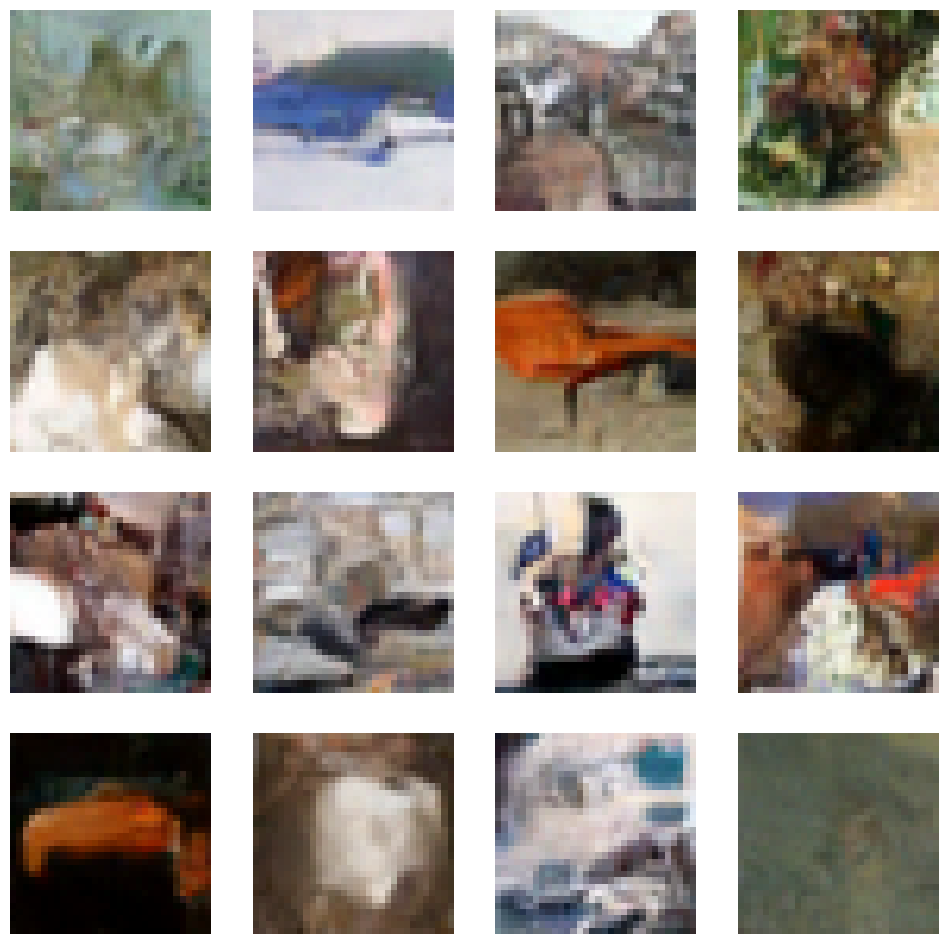

In [39]:
# Train with W&B logging
# This will:
# 1. Initialize a W&B run (may ask you to login first time)
# 2. Log loss after each batch
# 3. Log metrics and samples after each epoch
# 4. Create an interactive dashboard at wandb.ai
learn.fit(epochs)

**After running:**

1. Go to https://wandb.ai to see your dashboard
2. Find your project 'ddpm_cifar10'
3. Click on your run to see:
   - Loss curves over time
   - Sample images at each epoch
   - Configuration and hyperparameters
   - System metrics (GPU usage, etc.)

---
## What W&B Shows You

### Loss Curves
```
Loss
  |
  |\                        
  | \                       
  |  \____                  
  |       \____            
  |            \____       
  +----------------------- Step
```

### Sample Images Over Time
```
Epoch 1:     Epoch 5:     Epoch 10:
[noise]      [blurry]     [recognizable]
[noise]      [blurry]     [recognizable]
```

### Configuration
```
lr: 0.001
epochs: 10
model: UNet2DModel
```

### System Metrics
```
GPU Memory: 12GB / 24GB
GPU Utilization: 95%
Training Speed: 2.5 it/s
```

---
## Summary

### CIFAR-10 Key Points

1. **Color images**: 3 channels (RGB) instead of 1 (grayscale)
2. **Native 32x32**: No padding needed (unlike Fashion MNIST's 28x28)
3. **More challenging**: Real-world objects require more model capacity
4. **Smaller batches**: Memory constraints with larger models

### Model Scaling

| Size | Parameters | block_out_channels |
|------|------------|-------------------|
| Small | ~16M | (32, 64, 128, 256) |
| Default | ~274M | (320, 640, 1280, 1280) |

### W&B Integration

1. **`wandb.init()`**: Start a run with project name and config
2. **`wandb.log()`**: Log metrics, images, and other data
3. **`wandb.finish()`**: Close the run

### WandBCB Callback

- Extends MetricsCB to add W&B logging
- Logs loss after each batch
- Logs metrics and sample images after each epoch
- Stores configuration for reproducibility

---
## Next Steps

1. **Train longer**: 50-100 epochs for good quality
2. **Tune hyperparameters**: Try different learning rates, batch sizes
3. **Compare models**: Use W&B to compare small vs large models
4. **Add more logging**: FID scores, learning rate, gradient norms
5. **Use W&B sweeps**: Automated hyperparameter search

---
## Getting Started with W&B

1. **Create account**: Go to https://wandb.ai and sign up (free)
2. **Install**: `pip install wandb`
3. **Login**: Run `wandb login` in terminal (once per machine)
4. **Use**: Add WandBCB to your training callbacks
5. **View**: Go to wandb.ai to see your runs